In [10]:
import pandas as pd

on presice que la colonne "release_date"est une date avec "parse_dates"

In [11]:
gross=pd.read_csv('/content/disney_movies_total_gross.csv',parse_dates=["release_date"])

In [12]:
gross.head()

,movie_title,release_date,genre,mpaa_rating,total_gross,inflation_adjusted_gross
0,Snow White and the Seven Dwarfs,1937-12-21,Musical,G,184925485,5228953251
1,Pinocchio,1940-02-09,Adventure,G,84300000,2188229052
2,Fantasia,1940-11-13,Musical,G,83320000,2187090808
3,Song of the South,1946-11-12,Adventure,G,65000000,1078510579
4,Cinderella,1950-02-15,Drama,G,85000000,920608730


In [13]:
gross.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   movie_title               579 non-null    object        
 1   release_date              579 non-null    datetime64[ns]
 2   genre                     562 non-null    object        
 3   mpaa_rating               523 non-null    object        
 4   total_gross               579 non-null    int64         
 5   inflation_adjusted_gross  579 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 27.3+ KB


le classement des 10 films Disney les plus rémunérants

In [14]:
inflation_adjusted_gross_desc=gross.sort_values("inflation_adjusted_gross",ascending=False)
inflation_adjusted_gross_desc.head(10)


,movie_title,release_date,genre,mpaa_rating,total_gross,inflation_adjusted_gross
0,Snow White and the Seven Dwarfs,1937-12-21,Musical,G,184925485,5228953251
1,Pinocchio,1940-02-09,Adventure,G,84300000,2188229052
2,Fantasia,1940-11-13,Musical,G,83320000,2187090808
8,101 Dalmatians,1961-01-25,Comedy,G,153000000,1362870985
6,Lady and the Tramp,1955-06-22,Drama,G,93600000,1236035515
3,Song of the South,1946-11-12,Adventure,G,65000000,1078510579
564,Star Wars Ep. VII: The Force Awakens,2015-12-18,Adventure,PG-13,936662225,936662225
4,Cinderella,1950-02-15,Drama,G,85000000,920608730
13,The Jungle Book,1967-10-18,Musical,Not Rated,141843000,789612346
179,The Lion King,1994-06-15,Adventure,G,422780140,761640898


Nous allons regrouper les films par genre puis par année afin d observer le revenu ajusté de chaque genre pour chaque année

In [15]:
gross['release_year'] = pd.DatetimeIndex(gross["release_date"]).year

group = gross.groupby(['genre','release_year'])['inflation_adjusted_gross'].mean()

genre_yearly = group.reset_index()

genre_yearly.head(10)

,genre,release_year,inflation_adjusted_gross
0,Action,1981,0.0
1,Action,1982,77184895.0
2,Action,1988,36053517.0
3,Action,1990,118358772.0
4,Action,1991,57918572.5
5,Action,1992,58965304.0
6,Action,1993,44682157.0
7,Action,1994,39545796.0
8,Action,1995,122162426.5
9,Action,1996,257755262.5


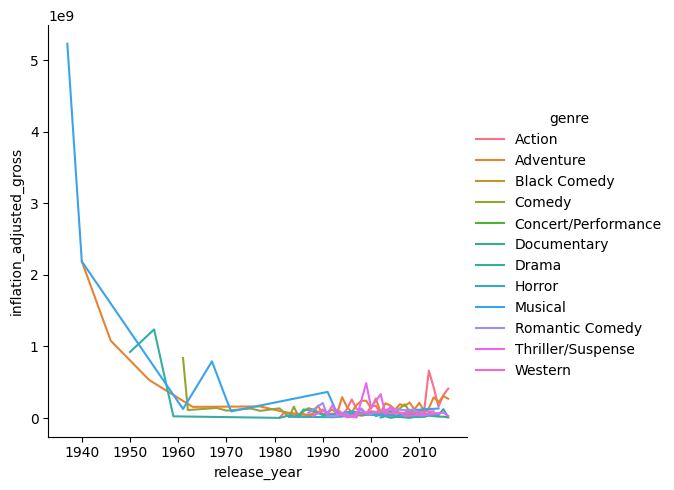

In [16]:
import seaborn as sns

sns.relplot(x='release_year', y='inflation_adjusted_gross', kind='line',
            hue='genre',
            data=genre_yearly)

représenter chaque genre par une colonne binaire (0/1), ce qui facilite l utilisation des algorithmes qui ne peuvent pas traiter directement des chaînes de caractères

In [18]:
genre_dummies = pd.get_dummies(data=gross['genre'], drop_first=True,dtype=int)

genre_dummies.head()

,Adventure,Black Comedy,Comedy,Concert/Performance,Documentary,Drama,Horror,Musical,Romantic Comedy,Thriller/Suspense,Western
0,0,0,0,0,0,0,0,1,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0


regression linéaire

In [19]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression()

regr.fit(genre_dummies, gross["inflation_adjusted_gross"])

action =  regr.intercept_
adventure = regr.coef_[[0]][0]

print((action, adventure))

(np.float64(102921757.36842039), np.float64(87475654.70909953))
